In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Updated URL for direct download from Google Drive
url = "https://drive.google.com/uc?export=download&id=1QX5YT-K7MrVfwJpKkMDXuuftzhikxS2R"
df = pd.read_csv(url)

# First few rows of the dataset
df.head()



,Student id,age,gender,Study_hours_per_day,social media_hours,netflix_hours,Part time_job,Attendance percentage,sleep_hours,diet_quality,Exercise frequency,parental_education_level,Internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [2]:
# Image folder setup

img_dir = "images"

if not os.path.exists(img_dir):
    os.makedirs(img_dir)
    print("Created 'images' folder for saving plots")
else:
    print("'images' folder already exists")

Created 'images' folder for saving plots


 Data Understanding

In [3]:
# ==============================
# 4.2 DATA UNDERSTANDING
# ==============================



# ---- Dataset Overview ----
print("🔹 Shape of dataset:", df.shape)
print("\n🔹 Column Names:\n", df.columns)

# ---- Data Types ----
print("\n🔹 Data Types:\n")
print(df.dtypes)

# ---- Sample Data ----
print("\n🔹 Sample Data (First 5 rows):\n")
print(df.head())

# ---- Summary Statistics ----
print("\n🔹 Summary Statistics:\n")
print(df.describe())

# ---- Missing Values ----
print("\n🔹 Missing Values:\n")
print(df.isnull().sum())

# ==============================
# DUPLICATE CHECK
# ==============================

print("\n🔹 Total Duplicate Rows:", df.duplicated().sum())

print("\n🔹 Duplicate Rows :\n")
print(df[df.duplicated(keep=False)])



🔹 Shape of dataset: (1020, 16)

🔹 Column Names:
 Index(['Student id', 'age', 'gender', 'Study_hours_per_day',
       'social media_hours', 'netflix_hours', 'Part time_job',
       'Attendance percentage', 'sleep_hours', 'diet_quality',
       'Exercise frequency', 'parental_education_level', 'Internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='str')

🔹 Data Types:

Student id                           str
age                                int64
gender                               str
Study_hours_per_day              float64
social media_hours               float64
netflix_hours                    float64
Part time_job                        str
Attendance percentage            float64
sleep_hours                      float64
diet_quality                         str
Exercise frequency                 int64
parental_education_level             str
Internet_quality                     str
mental_health_rating               int64

Data Cleaning and Preparation

In [4]:
# ==============================
# 4.3 DATA CLEANING & PREPARATION
# ==============================



# ------------------------------
# STEP 1: DUPLICATE HANDLING
# ------------------------------

# Remove duplicates if any exist
df = df.drop_duplicates()
duplicate_count = df.duplicated().sum()
print("After removing duplicates:", duplicate_count)

# ------------------------------
# STEP 2: COLUMN STANDARDIZATION
# ------------------------------
df.columns = df.columns.str.lower().str.replace(" ", "_")

print("\nStandardized Column Names:\n", df.columns)

# ------------------------------
# STEP 3: MISSING VALUE  & HANDLING


# Fill missing values with MODE
mode_value = df['parental_education_level'].mode()[0]
df['parental_education_level'] = df['parental_education_level'].fillna(mode_value)

# Verify after filling
print("\nMissing values after:\n")
print(df['parental_education_level'].isnull().sum())





After removing duplicates: 0

Standardized Column Names:
 Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='str')

Missing values after:

0


--- Outlier Detection (IQR Method) ---

Column: age
Outliers count: 0

Column: study_hours_per_day
Outliers count: 7
     study_hours_per_day
73                   7.4
293                  7.4
455                  8.3
489                  7.4
774                  7.5

Column: social_media_hours
Outliers count: 5
     social_media_hours
145                 6.2
346                 6.0
361                 6.1
641                 5.7
735                 7.2

Column: netflix_hours
Outliers count: 4
     netflix_hours
81             5.0
556            5.4
822            5.3
887            4.9

Column: attendance_percentage
Outliers count: 3
     attendance_percentage
651                   57.6
706                   56.7
971                   56.0

Column: sleep_hours
Outliers count: 2
     sleep_hours
802         10.0
955         10.0

Column: exercise_frequency
Outliers count: 0

Column: mental_health_rating
Outliers count: 0

Column: exam_score
Outliers count: 2
     exam_score
265        1

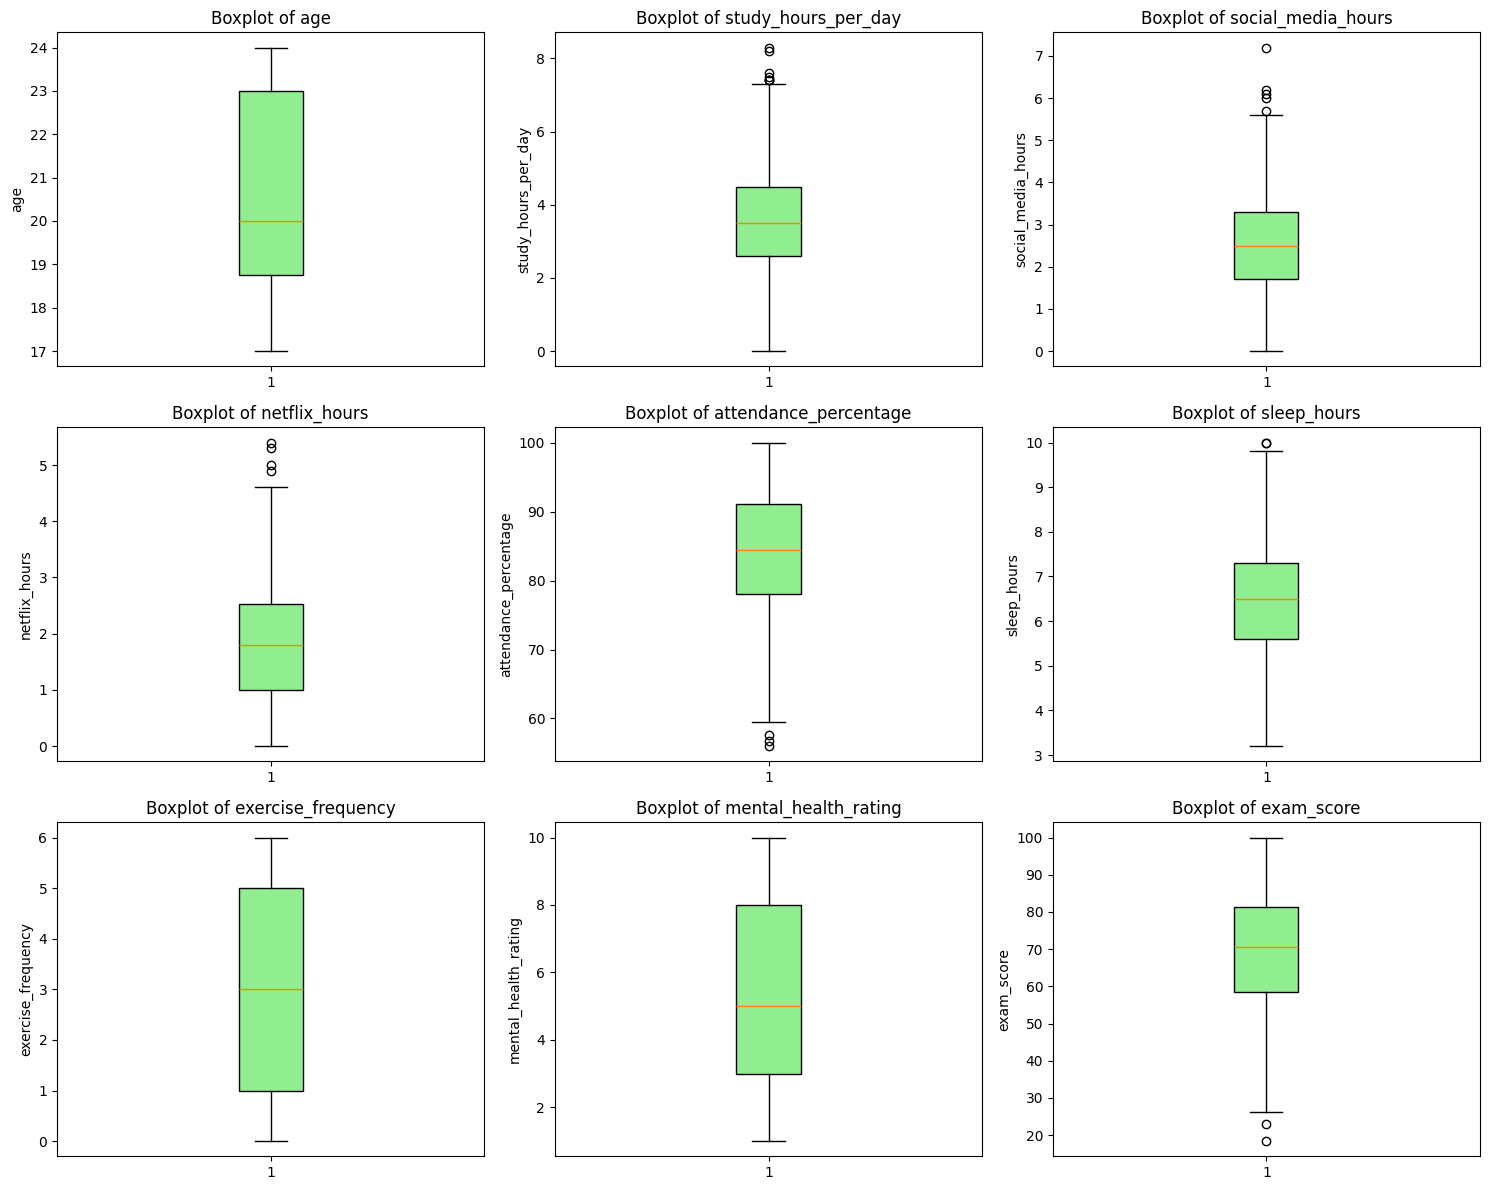

In [5]:
# ==============================
# 1. OUTLIER DETECTION (USING IQR)
# 2. MULTI-PANEL BOXPLOT VISUALIZATION
# ==============================


# --- Part 1: IQR Outlier Calculation ---
numeric_cols = df.select_dtypes(include=[np.number]).columns

print("--- Outlier Detection (IQR Method) ---")
for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print("\n==============================")
    print("Column:", col)
    print("Outliers count:", len(outliers))
    if len(outliers) > 0:
        print(outliers[[col]].head())


# --- Part 2: Multi-panel Boxplot Visualization ---

cols_to_plot = ['age', 'study_hours_per_day', 'social_media_hours',
                'netflix_hours', 'attendance_percentage', 'sleep_hours',
                'exercise_frequency', 'mental_health_rating', 'exam_score']


fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten() 
for i, col in enumerate(cols_to_plot):
    
    axes[i].boxplot(df[col].dropna(), patch_artist=True, boxprops=dict(facecolor='lightgreen'))

    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig("images/Outlier_Detection_BoxPlot.png")

plt.show()

In [6]:
# ==============================
# 4.4 FEATURE ENGINEERING 
# ==============================


# ------------------------------
# 1. STUDY CATEGORY (for grouping)
# ------------------------------
def study_category(x):
    if x < 2:
        return "Low"
    elif x <= 5:
        return "Medium"
    else:
        return "High"

df['study_category'] = df['study_hours_per_day'].apply(study_category)

# ------------------------------
# 2. TOTAL SCREEN TIME
# ------------------------------
df['total_screen_time'] = df['social_media_hours'] + df['netflix_hours']

# ------------------------------
# 3. STUDY EFFICIENCY (KEY FEATURE)
# ------------------------------
df['study_efficiency'] = df['exam_score'] / (df['study_hours_per_day'] + 0.01)

# ------------------------------
# 4. ENTERTAINMENT RATIO 
# ------------------------------
df['entertainment_ratio'] = df['total_screen_time'] / (df['study_hours_per_day'] + 0.01)

# ------------------------------
# 5. SLEEP CATEGORY
# ------------------------------
def sleep_category(x):
    if x < 6:
        return "Low"
    elif x <= 8:
        return "Normal"
    else:
        return "High"

df['sleep_category'] = df['sleep_hours'].apply(sleep_category)

# ------------------------------
# CHECK FEATURES
# ------------------------------
df[['study_category','total_screen_time','study_efficiency',
    'entertainment_ratio','sleep_category']].head()

,study_category,total_screen_time,study_efficiency,entertainment_ratio,sleep_category
0,Low,2.3,5620.000000,230.000000,Normal
1,High,5.1,14.471780,0.738061,Low
2,Low,4.4,24.326241,3.120567,Normal
3,Low,4.9,26.534653,4.851485,High
4,Medium,4.9,13.253493,0.978044,Low
